# pandas1

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Обзор

In [80]:
data = {
    "year": [
        2022, 2022, 2022, 2022,
        2023, 2023, 2023, 2023,
        2024, 2024
    ],
    "crop": [
        "wheat", "barley", "corn", "wheat",
        "wheat", "barley", "corn", "wheat",
        "wheat", "corn"
    ],
    "yield_t_per_ha": [
        3.2, 2.8, 5.0, 3.0,
        3.5, 2.9, 5.2, 2.7,
        3.3, 5.1
    ],
    "region": [
        "Central", "Central", "Central", "North",
        "South", "South", "South", "North",
        "North", "South"
    ]
}

df_yield = pd.DataFrame(data)
df_yield

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
1,2022,barley,2.8,Central
2,2022,corn,5.0,Central
3,2022,wheat,3.0,North
4,2023,wheat,3.5,South
5,2023,barley,2.9,South
6,2023,corn,5.2,South
7,2023,wheat,2.7,North
8,2024,wheat,3.3,North
9,2024,corn,5.1,South


In [81]:
df_yield.head()

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
1,2022,barley,2.8,Central
2,2022,corn,5.0,Central
3,2022,wheat,3.0,North
4,2023,wheat,3.5,South


In [82]:
df_yield.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            10 non-null     int64  
 1   crop            10 non-null     str    
 2   yield_t_per_ha  10 non-null     float64
 3   region          10 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 452.0 bytes


In [83]:
df_yield.describe()

,year,yield_t_per_ha
count,10.000000,10.000000
mean,2022.800000,3.670000
std,0.788811,1.015491
min,2022.000000,2.700000
25%,2022.000000,2.925000
50%,2023.000000,3.250000
75%,2023.000000,4.625000
max,2024.000000,5.200000


# Работа со столбцами

In [84]:
df_yield['crop']

0     wheat
1    barley
2      corn
3     wheat
4     wheat
5    barley
6      corn
7     wheat
8     wheat
9      corn
Name: crop, dtype: str

In [85]:
df_yield[['year', 'yield_t_per_ha']]

,year,yield_t_per_ha
0,2022,3.2
1,2022,2.8
2,2022,5.0
3,2022,3.0
4,2023,3.5
5,2023,2.9
6,2023,5.2
7,2023,2.7
8,2024,3.3
9,2024,5.1


In [86]:
df_yield.loc[0]

year                 2022
crop                wheat
yield_t_per_ha        3.2
region            Central
Name: 0, dtype: object

In [87]:
df_yield.iloc[[2, 7]]

,year,crop,yield_t_per_ha,region
2,2022,corn,5.0,Central
7,2023,wheat,2.7,North


# Фильтрация данных

In [88]:
df_yield[df_yield['crop'] == 'wheat']

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
3,2022,wheat,3.0,North
4,2023,wheat,3.5,South
7,2023,wheat,2.7,North
8,2024,wheat,3.3,North


In [89]:
df_yield[df_yield['yield_t_per_ha'] > 3.0]

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
2,2022,corn,5.0,Central
4,2023,wheat,3.5,South
6,2023,corn,5.2,South
8,2024,wheat,3.3,North
9,2024,corn,5.1,South


In [90]:
df_yield[(df_yield['year'] == 2023) & (df_yield['region'] == "South")]

,year,crop,yield_t_per_ha,region
4,2023,wheat,3.5,South
5,2023,barley,2.9,South
6,2023,corn,5.2,South


In [91]:
df_yield.query("crop == 'wheat'")

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
3,2022,wheat,3.0,North
4,2023,wheat,3.5,South
7,2023,wheat,2.7,North
8,2024,wheat,3.3,North


In [92]:
df_yield.query("yield_t_per_ha > 3.0")

,year,crop,yield_t_per_ha,region
0,2022,wheat,3.2,Central
2,2022,corn,5.0,Central
4,2023,wheat,3.5,South
6,2023,corn,5.2,South
8,2024,wheat,3.3,North
9,2024,corn,5.1,South


In [93]:
df_yield.query("year == 2023 & region == 'South'")

,year,crop,yield_t_per_ha,region
4,2023,wheat,3.5,South
5,2023,barley,2.9,South
6,2023,corn,5.2,South


# (!) Сортировка и вычисление новых столбцов

In [117]:
df_yield['yield_t_per_ha'].sort_values(ascending=False)

6    5.2
9    5.1
2    5.0
4    3.5
8    3.3
0    3.2
3    3.0
5    2.9
1    2.8
7    2.7
Name: yield_t_per_ha, dtype: float64

In [95]:
df_yield.sort_values(by=["year", "yield_t_per_ha"], ascending=[True, False])

,year,crop,yield_t_per_ha,region
2,2022,corn,5.0,Central
0,2022,wheat,3.2,Central
3,2022,wheat,3.0,North
1,2022,barley,2.8,Central
6,2023,corn,5.2,South
4,2023,wheat,3.5,South
5,2023,barley,2.9,South
7,2023,wheat,2.7,North
9,2024,corn,5.1,South
8,2024,wheat,3.3,North


# Новый столбец "урожайность в ц/га"

In [96]:
df_yield['yield_c_per_ha'] = df_yield['yield_t_per_ha'].apply(lambda x: x * 10)

In [97]:
df_yield['yield_c_per_ha']

0    32.0
1    28.0
2    50.0
3    30.0
4    35.0
5    29.0
6    52.0
7    27.0
8    33.0
9    51.0
Name: yield_c_per_ha, dtype: float64

# (!) Средняя урожайность

In [98]:
def calculate_mean(cols: str | list[str]):
    print(df_yield.groupby(cols)['yield_t_per_ha'].mean())

In [99]:
calculate_mean('crop')

crop
barley    2.85
corn      5.10
wheat     3.14
Name: yield_t_per_ha, dtype: float64


In [100]:
calculate_mean('region')

region
Central    3.666667
North      3.000000
South      4.175000
Name: yield_t_per_ha, dtype: float64


In [101]:
calculate_mean(['year', 'crop'])

year  crop  
2022  barley    2.8
      corn      5.0
      wheat     3.1
2023  barley    2.9
      corn      5.2
      wheat     3.1
2024  corn      5.1
      wheat     3.3
Name: yield_t_per_ha, dtype: float64


# (!) Сводная таблица

In [102]:
pivot = pd.pivot_table(
    df_yield,
    values="yield_t_per_ha",
    index="region",
    columns="crop",
    aggfunc="mean"
)
pivot

crop,barley,corn,wheat
region,,,
Central,2.8,5.00,3.2
North,NaN,NaN,3.0
South,2.9,5.15,3.5


# Задача 10. Поля и удобрения (inner join)

In [ ]:
data_fields = {
"field_id": [101, 102, 201],
"region": ["North", "North", "South"],
"area_ha": [15, 22, 30],
}
df_fields = pd.DataFrame(data_fields)

data_fert = {
"field_id": [101, 102, 201],
"fertilizer_kg_per_ha": [120, 100, 90],
}
df_fert = pd.DataFrame(data_fert)

In [104]:
df_join = pd.merge(
    df_fields,
    df_fert,
    on='field_id',
    how='inner',
)

df_join['fertilizier_total_kg'] = (
    df_join['area_ha'] * df_join['fertilizer_kg_per_ha']
)

df_join_sorted = df_join.sort_values('region')

In [105]:
df_join_sorted

,field_id,region,area_ha,fertilizer_kg_per_ha,fertilizier_total_kg
0,101,North,15,120,1800
1,102,North,22,100,2200
2,201,South,30,90,2700


# Задача 11. Left join с пропусками

In [106]:
data_fert2 = {
"field_id": [101, 201], # для 102 нет данных
"fertilizer_kg_per_ha": [120, 90],
}
df_fert2 = pd.DataFrame(data_fert2)

In [107]:
df_join_left = pd.merge(
    df_fields,
    df_fert2,
    on='field_id',
    how='left',
)
df_join_left

,field_id,region,area_ha,fertilizer_kg_per_ha
0,101,North,15,120.0
1,102,North,22,NaN
2,201,South,30,90.0


# Задача 12. Бинарный признак «орошение»

In [108]:
data_cat = {
"field_id": [1, 2, 3, 4, 5],
"region": ["North", "North", "South", "South", "South"],
"crop": ["wheat", "wheat", "corn", "corn", "wheat"],
"soil_type": ["chernozem", "sod-podzolic", "chestnut", "chestnut", "chestnut"],
"irrigation": ["yes", "no", "yes", "no", "yes"],
}
df_cat = pd.DataFrame(data_cat)
df_cat

,field_id,region,crop,soil_type,irrigation
0,1,North,wheat,chernozem,yes
1,2,North,wheat,sod-podzolic,no
2,3,South,corn,chestnut,yes
3,4,South,corn,chestnut,no
4,5,South,wheat,chestnut,yes


In [ ]:
df_cat['irrigation_bin'] = df_cat['irrigation'].map({'yes': 1, 'no': 0})
df_cat

,field_id,region,crop,soil_type,irrigation,irrigation_bin
0,1,North,wheat,chernozem,yes,1
1,2,North,wheat,sod-podzolic,no,0
2,3,South,corn,chestnut,yes,1
3,4,South,corn,chestnut,no,0
4,5,South,wheat,chestnut,yes,1


# Задача 13. One-hot кодирование культур

In [110]:
df_cat_dummies = pd.get_dummies(df_cat, columns=['crop'], drop_first=True)
df_cat_dummies

,field_id,region,soil_type,irrigation,irrigation_bin,crop_wheat
0,1,North,chernozem,yes,1,True
1,2,North,sod-podzolic,no,0,True
2,3,South,chestnut,yes,1,False
3,4,South,chestnut,no,0,False
4,5,South,chestnut,yes,1,True


# Задача 14. Диаграммы средней урожайности

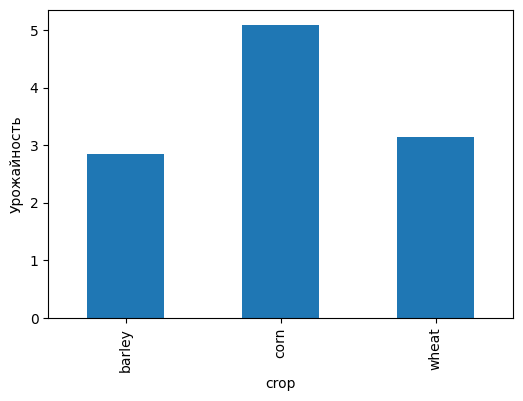

In [115]:
avg_crop = df_yield.groupby("crop")["yield_t_per_ha"].mean()
plt.figure(figsize=(6, 4))
avg_crop.plot(kind="bar")
plt.ylabel("Урожайность")
plt.show()

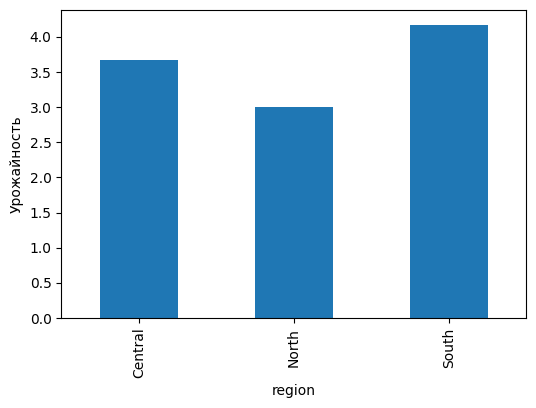

In [114]:
avg_region = df_yield.groupby("region")["yield_t_per_ha"].mean()
plt.figure(figsize=(6, 4))
avg_region.plot(kind="bar")
plt.ylabel("Урожайность")
plt.show()